In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import math
from scipy import stats

In [90]:
data = pd.read_csv('Market.csv', header=4)
#data.head()
data.sample(10)

,Date,Hour,Time Block,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
2458,01-06-2026,15,14:30 - 14:45,10788.20,35905.60,9284.40,9284.40,1940.23,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1041,17-05-2026,21,20:15 - 20:30,14069.40,3978.40,3943.90,3943.90,10000.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2496,02-06-2026,1,00:00 - 00:15,19879.50,4207.30,3470.69,3470.69,10000.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,28-05-2026,2,01:15 - 01:30,37553.90,2445.20,2142.28,2142.28,10000.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1939,27-05-2026,5,04:45 - 05:00,19054.90,2751.10,2321.40,2321.40,10000.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2872,05-06-2026,23,22:00 - 22:15,28694.50,1320.00,1313.20,1313.20,10000.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,08-05-2026,9,08:00 - 08:15,9812.20,36665.00,7161.42,7161.42,1611.48,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3041,23-05-2026,Total (MWh),587225.48,356303.20,142698.58,142698.58,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202,19-05-2026,13,12:30 - 12:45,13203.30,45350.10,8890.82,8890.82,1650.74,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1306,20-05-2026,15,14:30 - 14:45,16467.00,34920.90,11095.14,11095.14,2483.47,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]
data = data.dropna(axis=1, how='all')

In [92]:
data.columns
data.shape

(3101, 8)

In [93]:
sum_data = data["MCP (Rs/MWh) *"].sum()
print("Sum of MCP (Rs/MWh:", sum_data)

mean_data = data["MCP (Rs/MWh) *"].mean()
print("Mean of MCP (Rs/MWh):", mean_data)

median_data = data["MCP (Rs/MWh) *"].median()
print("Median of MCP (Rs/MWh):", median_data)

max_value = data["MCP (Rs/MWh) *"].max()
print("Max of MCP (Rs/MWh):", max_value)

min_value = data["MCP (Rs/MWh) *"].min()
print("Min of MCP (Rs/MWh):", min_value)

Sum of MCP (Rs/MWh: 15749786.620000001
Mean of MCP (Rs/MWh): 5292.2670094086025
Median of MCP (Rs/MWh): 3956.705
Max of MCP (Rs/MWh): 10000.0
Min of MCP (Rs/MWh): 20.81


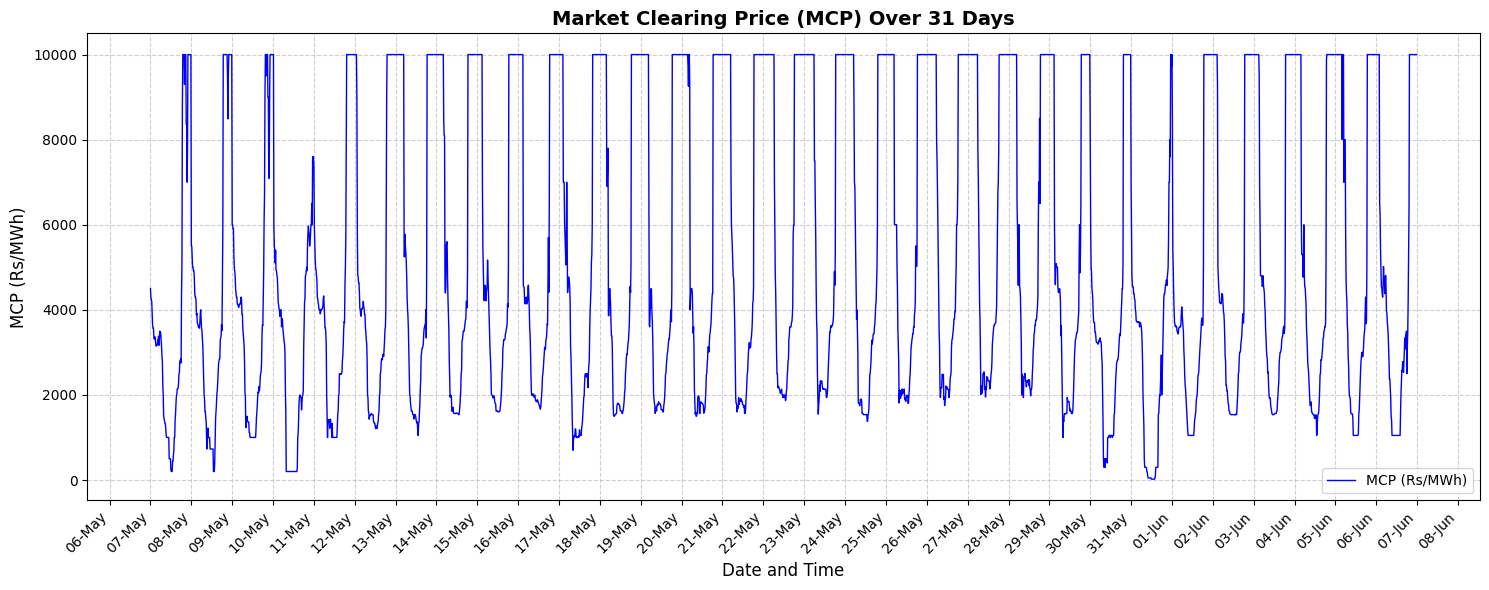

In [94]:
df = data.dropna(subset=['Date', 'Time Block', 'MCP (Rs/MWh) *'])
data = df.copy()

start_time = data['Time Block'].str.split('-').str[0].str.strip()

# 3. Combine 'Date' and the extracted 'start_time' into a single string
datetime_str = data['Date'] + ' ' + start_time

# 4. Convert the combined string to a pandas datetime object
# The format specifies Day-Month-Year and Hour:Minute
data['Datetime'] = pd.to_datetime(datetime_str, format='%d-%m-%Y %H:%M')

# 5. Create the Plot
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(data['Datetime'], data['MCP (Rs/MWh) *'], label='MCP (Rs/MWh)', color='b', linewidth=1)

# --- Formatting the Graph to be Clean and Tidy ---

# Format the x-axis to show 'Day-Month' nicely
# Showing a tick for each day since it is a 31-day period
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

# Rotate the dates so they don't crush together
plt.xticks(rotation=45, ha='right')

# Add Labels, Title, and Grid
ax.set_title('Market Clearing Price (MCP) Over 31 Days', fontsize=14, fontweight='bold')
ax.set_xlabel('Date and Time', fontsize=12)
ax.set_ylabel('MCP (Rs/MWh)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()

# Tight layout ensures everything fits perfectly without cutting off labels
plt.tight_layout()

# Display the plot
plt.show()

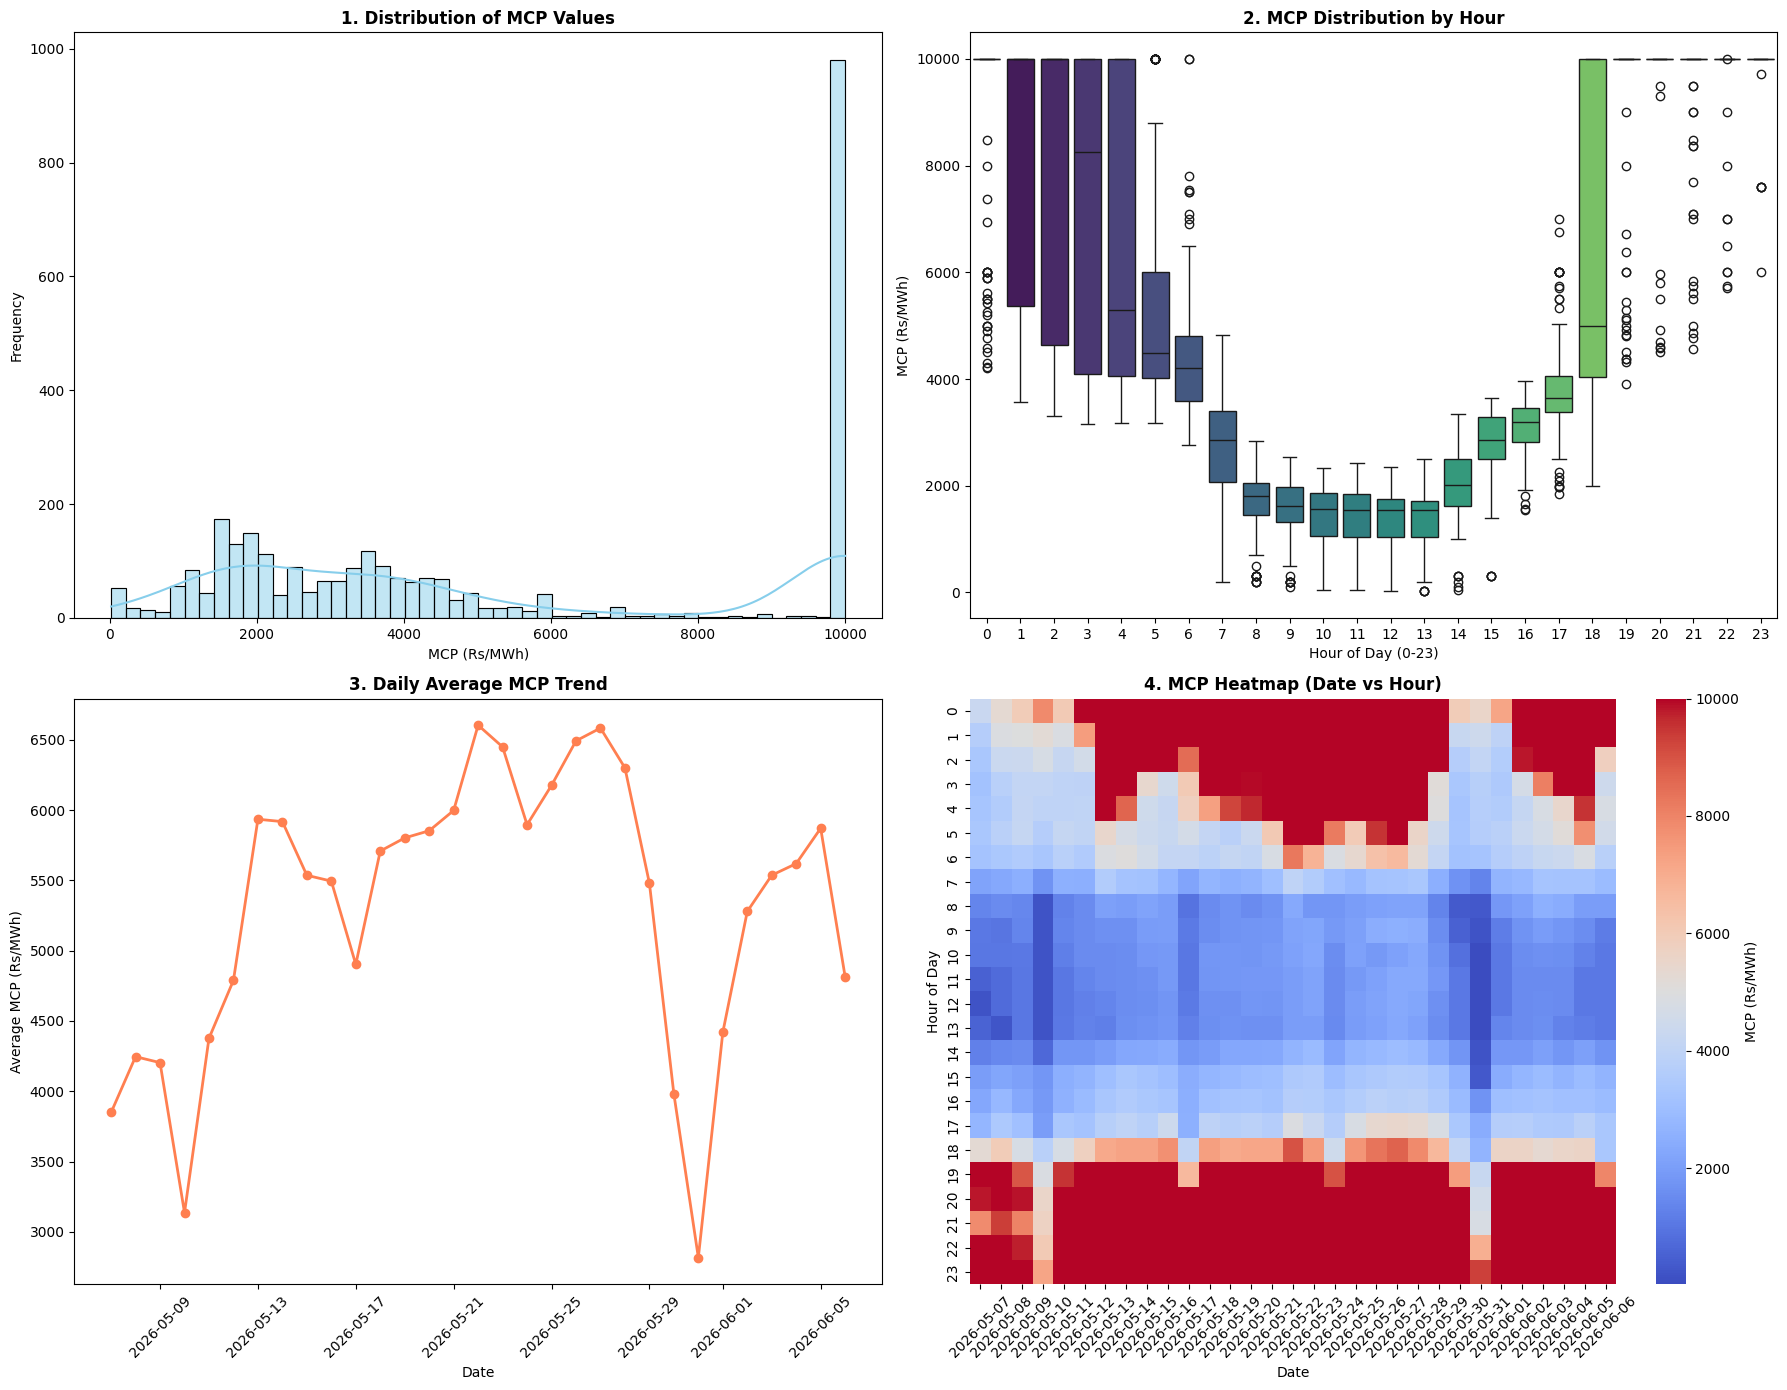

In [95]:
# Create additional columns for easier plotting
data['HourOfDay'] = data['Datetime'].dt.hour
data['DateOnly'] = data['Datetime'].dt.date

# Set up the figure with 4 subplots (2 rows by 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Distribution of MCP values (Histogram)
sns.histplot(data=data, x='MCP (Rs/MWh) *', bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Distribution of MCP Values', fontweight='bold')
axes[0, 0].set_xlabel('MCP (Rs/MWh)')
axes[0, 0].set_ylabel('Frequency')

# 2. MCP Distribution by Hour of Day (Box Plot)
sns.boxplot(data=data, x='HourOfDay', y='MCP (Rs/MWh) *', hue='HourOfDay', legend=False, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('2. MCP Distribution by Hour', fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day (0-23)')
axes[0, 1].set_ylabel('MCP (Rs/MWh)')

# 3. Daily Average MCP trend (Line Plot)
daily_avg = data.groupby('DateOnly')['MCP (Rs/MWh) *'].mean().reset_index()
axes[1, 0].plot(daily_avg['DateOnly'], daily_avg['MCP (Rs/MWh) *'], marker='o', color='coral', linewidth=2)
axes[1, 0].set_title('3. Daily Average MCP Trend', fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Average MCP (Rs/MWh)')

# Rotate dates for the line plot to avoid overlap
for tick in axes[1, 0].get_xticklabels():
    tick.set_rotation(45)

# 4. MCP Heatmap (Average MCP by Date and Hour)
# Pivot table with HourOfDay as index (y-axis) and Date as columns (x-axis)
heatmap_data = data.pivot_table(index='HourOfDay', columns='DateOnly', values='MCP (Rs/MWh) *', aggfunc='mean')

# Plot the heatmap
sns.heatmap(heatmap_data, cmap='coolwarm', ax=axes[1, 1], cbar_kws={'label': 'MCP (Rs/MWh)'})
axes[1, 1].set_title('4. MCP Heatmap (Date vs Hour)', fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Hour of Day')

# Rotate x-axis dates for the heatmap as well to avoid overlapping text
for tick in axes[1, 1].get_xticklabels():
    tick.set_rotation(45)

# Adjust layout so plots don't overlap
plt.tight_layout()
plt.show()

In [96]:
data = data.sort_values(by='Datetime').reset_index(drop=True)

# Extract the MCP (Rs/MWh) values
mcp_values = data['MCP (Rs/MWh) *'].values

X_t = mcp_values[:-1].reshape(-1, 1) # Sklearn expects a 2D array for X
X_t_plus_1 = mcp_values[1:]

# Initialize and fit the Ordinary Least Squares (Linear Regression) model
ols_model = LinearRegression()
ols_model.fit(X_t, X_t_plus_1)

# Generate predictions based on the fitted model
predictions = ols_model.predict(X_t)
residuals = X_t_plus_1 - predictions

n = len(X_t_plus_1)
RSE = np.sqrt(np.sum(residuals**2) / (n - 2))  # For σ estimation

beta = ols_model.coef_[0]
alpha = ols_model.intercept_
n_steps = len(mcp_values)

# Output the results
print("--- OLS (Ordinary Least Squares) Results ---")
print(f"Beta Coefficient (Slope): {ols_model.coef_[0]:.6f}")
print(f"Alpha (Intercept):   {ols_model.intercept_:.4f}")
print(f"R-squared:           {r2_score(X_t_plus_1, predictions):.4f}")
print(f"MSE:                 {mean_squared_error(X_t_plus_1, predictions):.4f}")
print(f"RSE:                 {RSE:.4f}")
print(f"Residuals saved:     {len(residuals)} values")

--- OLS (Ordinary Least Squares) Results ---
Beta Coefficient (Slope): 0.984333
Alpha (Intercept):   84.7368
R-squared:           0.9684
MSE:                 406005.1193
RSE:                 637.3996
Residuals saved:     2975 values


In [97]:
del_t = 0.25
theta = -math.log(beta) / del_t
mu = alpha / (1 - beta)
n = len(X_t_plus_1)
RSE = np.sqrt(np.sum(residuals**2) / (n - 2))
sig1 = 2*theta
sig2 = -(2*theta*del_t)
sig3 = 1-math.exp(sig2)
sigma = RSE * math.sqrt(sig1/sig3)
print(f"theta:{theta:.6f}")
print(f"mu:{mu:.6f}")
print(f"sigma:{sigma:.6f}")



theta:0.063163
mu:5408.708689
sigma:1284.877355


In [98]:
decay = math.exp(-(theta*del_t))
mean_pull = mu * (1 - decay)
noise_std = sigma * np.sqrt((1 - np.exp(-2 * theta * del_t)) / (2 * theta))

n_paths = 200
X_sim = np.zeros((n_steps, n_paths))
X_sim[0, :] = mcp_values[0] 
print(X_sim.shape)

for t in range(n_steps - 1):
    Z_t = np.random.normal(0, 1, size=n_paths)  # Standard normal random variable
    X_sim[t+1, :] = X_sim[t, :] * decay + mean_pull + noise_std * Z_t

(2976, 200)


Text(0.5, 0.8, 'Actual has 3.4× more cap hits')

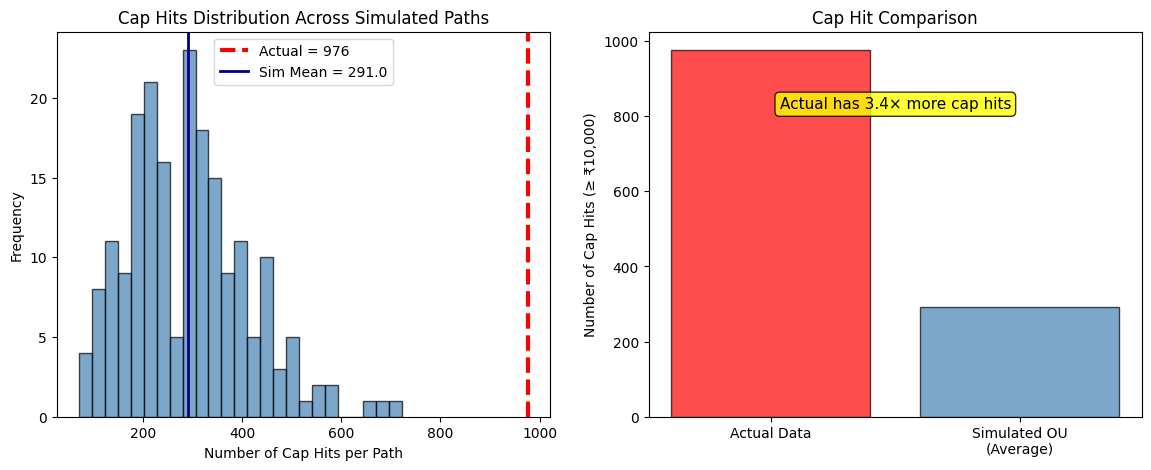

In [99]:
# ============================================
# CORRECTED CAP HIT CALCULATION
# ============================================
PRICE_CAP = 10000

# Actual cap hits
actual_cap_hits_total = np.sum(mcp_values >= PRICE_CAP)
actual_cap_hit_percentage = (actual_cap_hits_total / n_steps) * 100

# Simulated cap hits per path
sim_cap_hits_per_path = np.sum(X_sim >= PRICE_CAP, axis=0)
sim_cap_hits_mean = np.mean(sim_cap_hits_per_path)
sim_cap_hits_std = np.std(sim_cap_hits_per_path)

# Ratio
ratio_actual_to_sim = actual_cap_hits_total / sim_cap_hits_mean

# For visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of cap hits across paths
ax1 = axes[0]
ax1.hist(sim_cap_hits_per_path, bins=25, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(actual_cap_hits_total, color='red', linewidth=3, linestyle='--', 
            label=f'Actual = {actual_cap_hits_total}')
ax1.axvline(sim_cap_hits_mean, color='darkblue', linewidth=2, linestyle='-', 
            label=f'Sim Mean = {sim_cap_hits_mean:.1f}')
ax1.set_title('Cap Hits Distribution Across Simulated Paths')
ax1.set_xlabel('Number of Cap Hits per Path')
ax1.set_ylabel('Frequency')
ax1.legend()

# Right: Bar comparison
ax2 = axes[1]
ax2.bar(['Actual Data', 'Simulated OU\n(Average)'], 
        [actual_cap_hits_total, sim_cap_hits_mean],
        color=['red', 'steelblue'], alpha=0.7, edgecolor='black')
ax2.set_title('Cap Hit Comparison')
ax2.set_ylabel('Number of Cap Hits (≥ ₹10,000)')
ax2.text(0.5, 0.8, f'Actual has {ratio_actual_to_sim:.1f}× more cap hits', 
         transform=ax2.transAxes, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

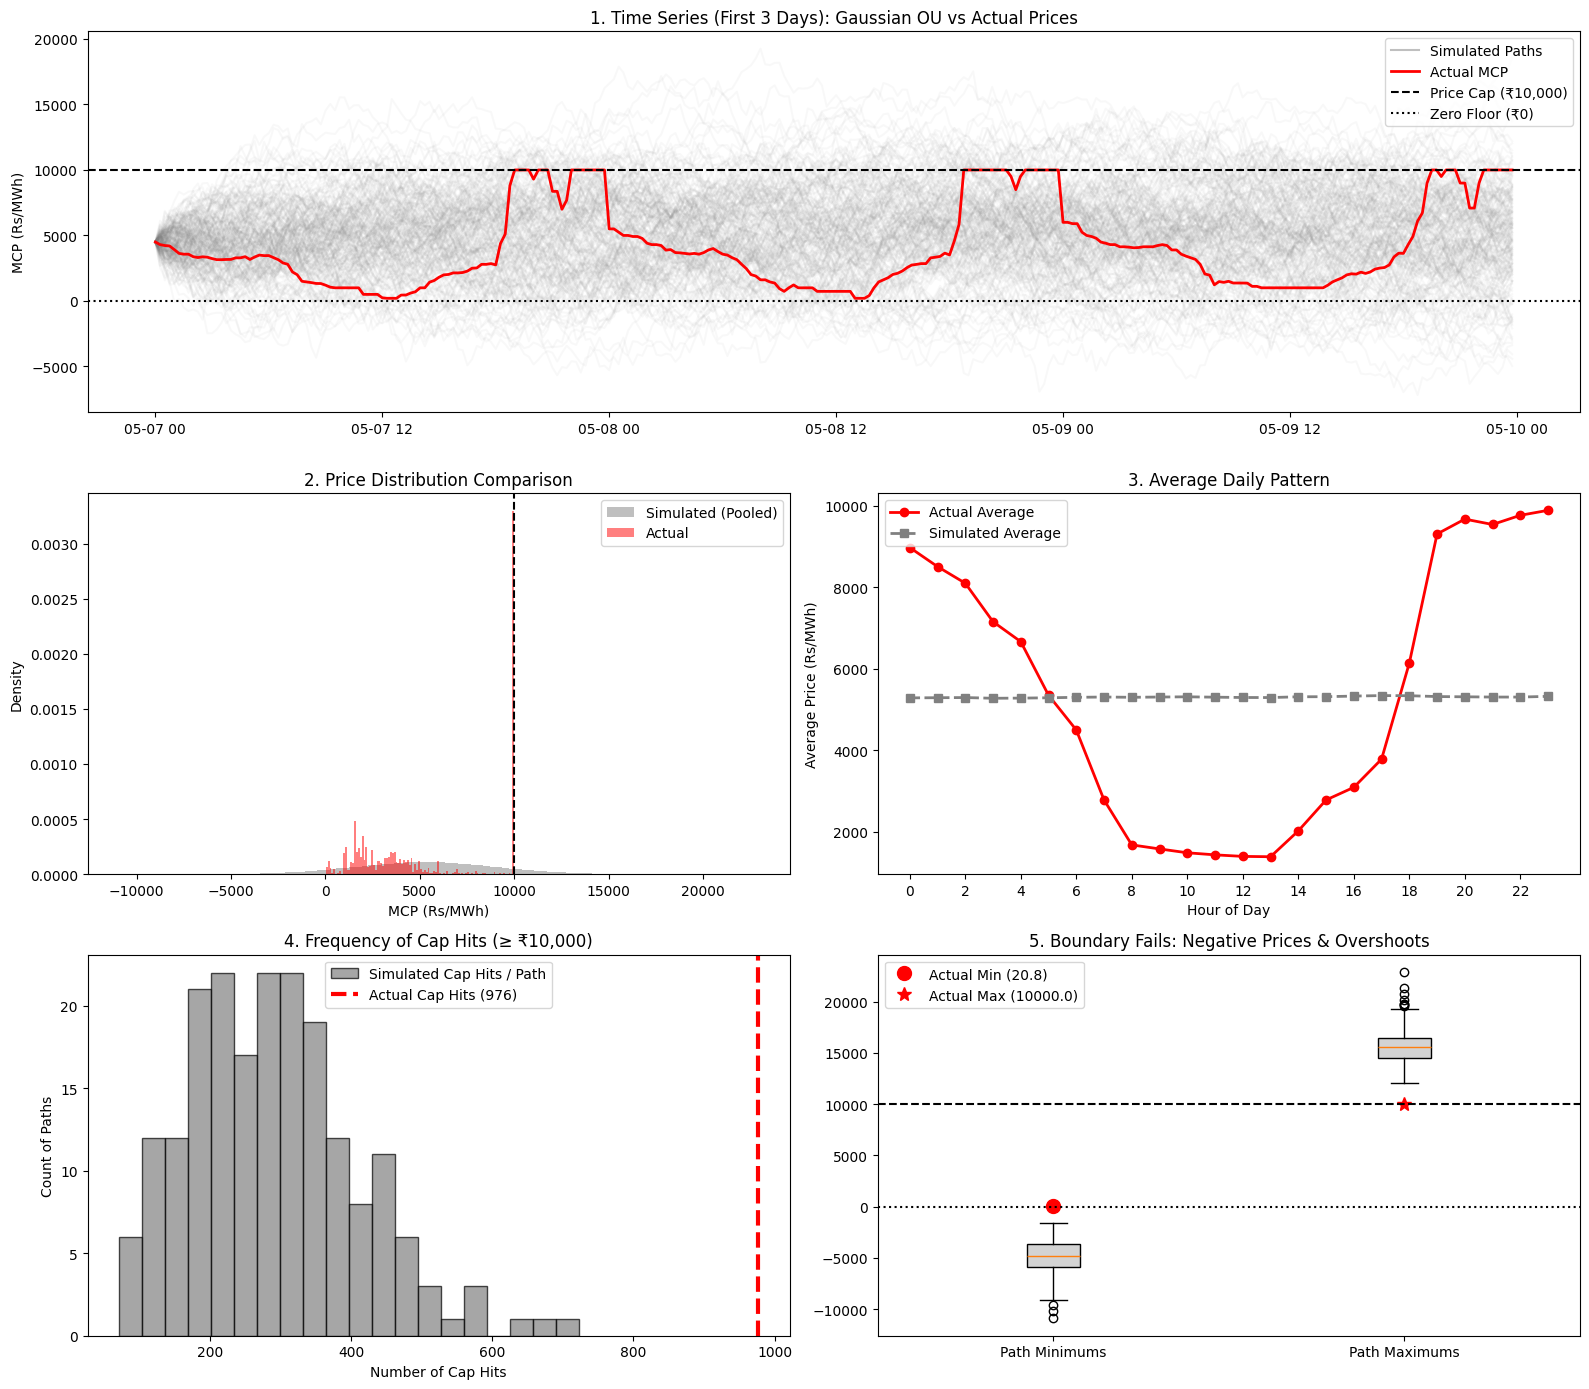

In [100]:
import matplotlib.pyplot as plt
import numpy as np

actual_prices = mcp_values
simulated_paths = X_sim
dates = data['Datetime']

# Assuming `actual_prices`, `simulated_paths`, and `dates` are already defined in the environment.
# Note: Based on previous cells, we can map them if they go by different names:
# actual_prices = mcp_values
# simulated_paths = X_sim
# dates = df['Datetime']

# Create a 3-row layout using subplot indexing.
fig = plt.figure(figsize=(16, 14))

# 1. Time series overlay (spanning the entire top row)
ax1 = plt.subplot(3, 1, 1)
n_zoom = 288 # First 3 days at 15-min frequency (4 * 24 * 3)

# Plot path distribution
ax1.plot(dates[:n_zoom], simulated_paths[:n_zoom, :], color='gray', alpha=0.05)
# Proxy line for the legend since we don't want 200 labels
ax1.plot([], [], color='gray', alpha=0.5, label='Simulated Paths') 
# Plot actual
ax1.plot(dates[:n_zoom], actual_prices[:n_zoom], color='red', linewidth=2, label='Actual MCP')

ax1.axhline(10000, color='black', linestyle='--', label='Price Cap (₹10,000)')
ax1.axhline(0, color='black', linestyle=':', label='Zero Floor (₹0)')
ax1.set_title("1. Time Series (First 3 Days): Gaussian OU vs Actual Prices")
ax1.set_ylabel("MCP (Rs/MWh)")
ax1.legend(loc='upper right')

# 2. Distribution comparison
ax2 = plt.subplot(3, 2, 3)
ax2.hist(simulated_paths.flatten(), bins=100, color='gray', alpha=0.5, density=True, label='Simulated (Pooled)')
ax2.hist(actual_prices, bins=100, color='red', alpha=0.5, density=True, label='Actual')
ax2.axvline(10000, color='black', linestyle='--')
ax2.set_title("2. Price Distribution Comparison")
ax2.set_xlabel("MCP (Rs/MWh)")
ax2.set_ylabel("Density")
ax2.legend()

# 3. Daily pattern comparison
ax3 = plt.subplot(3, 2, 4)
hours = dates.dt.hour # Assuming dates is a pandas DatetimeIndex

# Calculate hourly averages manually without seaborn/pandas groupby
actual_hourly = [np.mean(actual_prices[hours == h]) for h in range(24)]
sim_hourly = [np.mean(simulated_paths[hours == h, :]) for h in range(24)]

ax3.plot(range(24), actual_hourly, marker='o', color='red', linewidth=2, label='Actual Average')
ax3.plot(range(24), sim_hourly, marker='s', color='gray', linestyle='--', linewidth=2, label='Simulated Average')
ax3.set_title("3. Average Daily Pattern")
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Average Price (Rs/MWh)")
ax3.set_xticks(range(0, 24, 2))
ax3.legend()

# 4. Cap hit analysis
ax4 = plt.subplot(3, 2, 5)
actual_cap_hits = np.sum(actual_prices >= 10000)
sim_cap_hits = np.sum(simulated_paths >= 10000, axis=0) # count per path (length 200)

ax4.hist(sim_cap_hits, bins=20, color='gray', alpha=0.7, edgecolor='black', label='Simulated Cap Hits / Path')
ax4.axvline(actual_cap_hits, color='red', linewidth=3, linestyle='--', label=f'Actual Cap Hits ({actual_cap_hits})')
ax4.set_title("4. Frequency of Cap Hits (≥ ₹10,000)")
ax4.set_xlabel("Number of Cap Hits")
ax4.set_ylabel("Count of Paths")
ax4.legend()

# 5. QQ-plot equivalent / Min-Max evaluation showing boundary failures
ax5 = plt.subplot(3, 2, 6)
actual_min = np.min(actual_prices)
actual_max = np.max(actual_prices)
sim_mins = np.min(simulated_paths, axis=0)
sim_maxs = np.max(simulated_paths, axis=0)

box_parts = ax5.boxplot([sim_mins, sim_maxs], positions=[1, 2], patch_artist=True)
for box in box_parts['boxes']:
    box.set_facecolor('lightgray')

ax5.set_xticks([1, 2])
ax5.set_xticklabels(['Path Minimums', 'Path Maximums'])
ax5.plot(1, actual_min, 'ro', markersize=10, label=f'Actual Min ({actual_min:.1f})')
ax5.plot(2, actual_max, 'r*', markersize=10, label=f'Actual Max ({actual_max:.1f})')
ax5.axhline(0, color='black', linestyle=':')
ax5.axhline(10000, color='black', linestyle='--')
ax5.set_title("5. Boundary Fails: Negative Prices & Overshoots")
ax5.legend()

plt.tight_layout()
plt.savefig("ou_failure_analysis.png", dpi=300)
plt.show()

  JARQUE-BERA NORMALITY TEST
  Actual MCP  →  JB =       357.18,  p = 2.7566e-78  REJECT H₀ (α=0.05)
                 Skewness = +0.3418,  Excess Kurtosis = -1.5535
  Simulated   →  JB =        16.32,  p = 2.8643e-04  REJECT H₀ (α=0.05)
                 Skewness = -0.1587,  Excess Kurtosis = +0.1757

  KOLMOGOROV-SMIRNOV TESTS
  Two-sample (Actual vs Sim mean)
    D = 0.570565,  p = 0.0000e+00  REJECT H₀ (α=0.05)
  One-sample (Actual vs fitted Normal)
    D = 0.234100,  p = 6.3797e-144  REJECT H₀ (α=0.05)

  ANDERSON-DARLING NORMALITY TEST
  Actual MCP  →  A² = 221.1794
     15.0% significance:  critical value = 0.5610  ***EXCEEDED***
     10.0% significance:  critical value = 0.6310  ***EXCEEDED***
      5.0% significance:  critical value = 0.7520  ***EXCEEDED***
      2.5% significance:  critical value = 0.8730  ***EXCEEDED***
      1.0% significance:  critical value = 1.0350  ***EXCEEDED***
  Simulated   →  A² = 3.2153
     15.0% significance:  critical value = 0.5610  ***EXCEEDED**

C:\Users\OMKAAR\AppData\Local\Temp\ipykernel_32424\1470295910.py:46: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_actual = stats.anderson(actual, dist='norm')
C:\Users\OMKAAR\AppData\Local\Temp\ipykernel_32424\1470295910.py:47: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated table

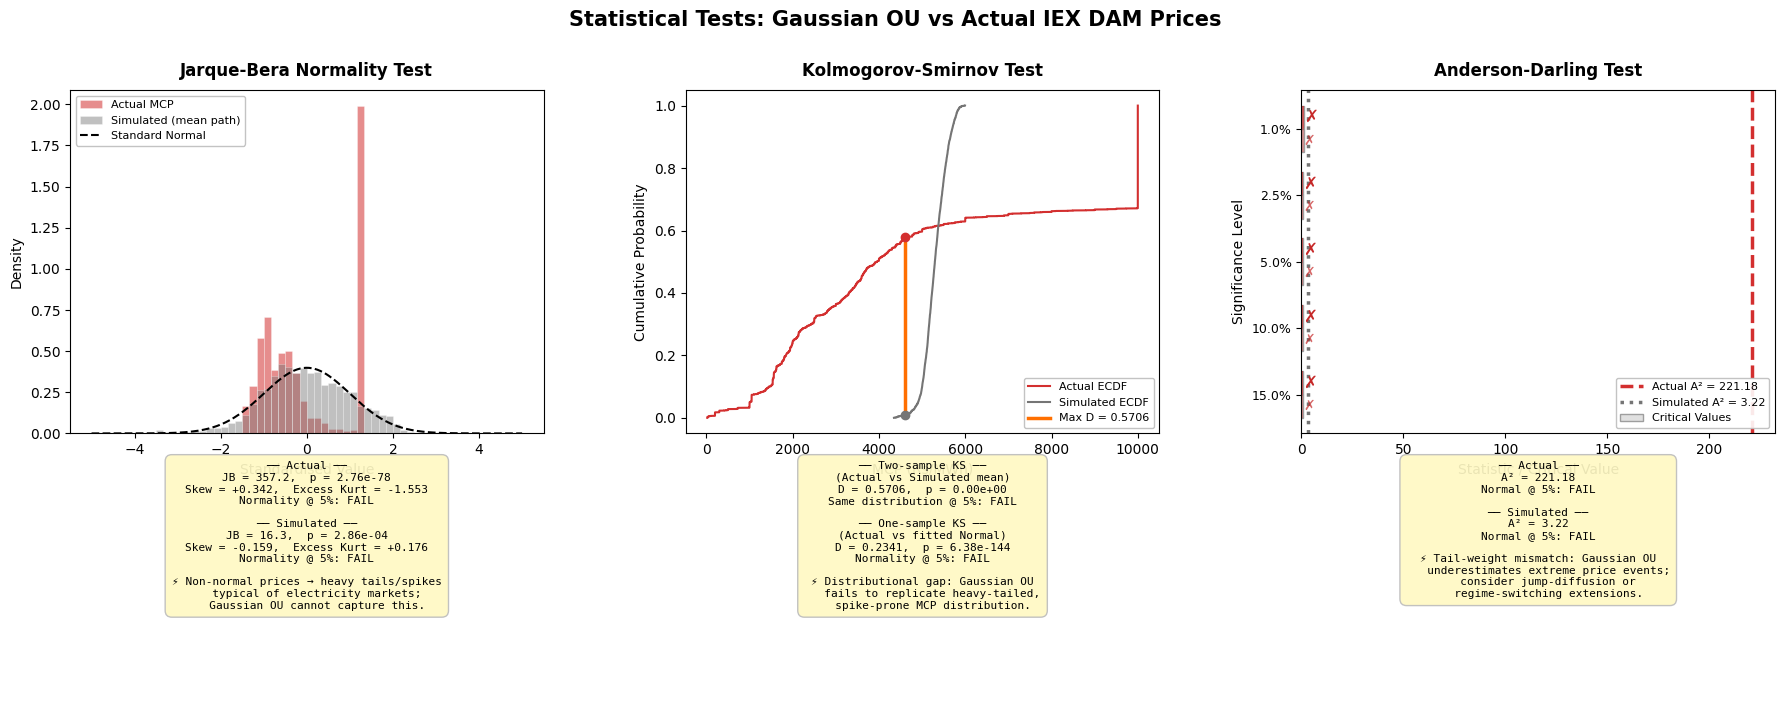


✅ Figure saved → statistical_tests_panel.png


In [101]:
actual = mcp_values.copy()
sim_mean = np.mean(X_sim, axis=1)          # representative simulated path

# ---------------------------------------------------------------------------
# 1.  Run all three tests and print results to console
# ---------------------------------------------------------------------------

# ── Jarque-Bera ──────────────────────────────────────────────────────────────
jb_actual_stat, jb_actual_p = stats.jarque_bera(actual)
jb_sim_stat, jb_sim_p       = stats.jarque_bera(sim_mean)

skew_actual   = stats.skew(actual)
kurt_actual   = stats.kurtosis(actual)          # excess kurtosis
skew_sim      = stats.skew(sim_mean)
kurt_sim      = stats.kurtosis(sim_mean)

print("=" * 72)
print("  JARQUE-BERA NORMALITY TEST")
print("=" * 72)
print(f"  Actual MCP  →  JB = {jb_actual_stat:>12.2f},  p = {jb_actual_p:.4e}"
      f"  {'REJECT H₀' if jb_actual_p < 0.05 else 'FAIL TO REJECT H₀'} (α=0.05)")
print(f"                 Skewness = {skew_actual:+.4f},  Excess Kurtosis = {kurt_actual:+.4f}")
print(f"  Simulated   →  JB = {jb_sim_stat:>12.2f},  p = {jb_sim_p:.4e}"
      f"  {'REJECT H₀' if jb_sim_p < 0.05 else 'FAIL TO REJECT H₀'} (α=0.05)")
print(f"                 Skewness = {skew_sim:+.4f},  Excess Kurtosis = {kurt_sim:+.4f}")
print()

# ── Kolmogorov-Smirnov ───────────────────────────────────────────────────────
ks2_stat, ks2_p = stats.ks_2samp(actual, sim_mean)
ks1_stat, ks1_p = stats.kstest(
    actual, 'norm', args=(np.mean(actual), np.std(actual, ddof=1))
)

print("=" * 72)
print("  KOLMOGOROV-SMIRNOV TESTS")
print("=" * 72)
print(f"  Two-sample (Actual vs Sim mean)")
print(f"    D = {ks2_stat:.6f},  p = {ks2_p:.4e}"
      f"  {'REJECT H₀' if ks2_p < 0.05 else 'FAIL TO REJECT H₀'} (α=0.05)")
print(f"  One-sample (Actual vs fitted Normal)")
print(f"    D = {ks1_stat:.6f},  p = {ks1_p:.4e}"
      f"  {'REJECT H₀' if ks1_p < 0.05 else 'FAIL TO REJECT H₀'} (α=0.05)")
print()

# ── Anderson-Darling ─────────────────────────────────────────────────────────
ad_actual = stats.anderson(actual, dist='norm')
ad_sim    = stats.anderson(sim_mean, dist='norm')

print("=" * 72)
print("  ANDERSON-DARLING NORMALITY TEST")
print("=" * 72)
print(f"  Actual MCP  →  A² = {ad_actual.statistic:.4f}")
for sl, cv in zip(ad_actual.significance_level, ad_actual.critical_values):
    exceeded = "***EXCEEDED***" if ad_actual.statistic > cv else ""
    print(f"    {sl:5.1f}% significance:  critical value = {cv:.4f}  {exceeded}")
print(f"  Simulated   →  A² = {ad_sim.statistic:.4f}")
for sl, cv in zip(ad_sim.significance_level, ad_sim.critical_values):
    exceeded = "***EXCEEDED***" if ad_sim.statistic > cv else ""
    print(f"    {sl:5.1f}% significance:  critical value = {cv:.4f}  {exceeded}")
print("=" * 72)
print()

# ---------------------------------------------------------------------------
# 2.  Build the figure  (22 × 8)
#     Top row  = 3 subplots (charts only, no annotation clutter)
#     Bottom   = annotation text boxes placed via fig.text() below each axis
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(22, 8))

# Use GridSpec: top 55% for plots, bottom 45% reserved for text boxes
gs = gridspec.GridSpec(
    2, 3,
    height_ratios=[1.0, 0.75],
    hspace=0.05,          # minimal gap — text boxes sit right below axes
    wspace=0.30
)

# Create the three plot axes (top row only)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Create invisible axes for text boxes (bottom row)
ax_txt1 = fig.add_subplot(gs[1, 0])
ax_txt2 = fig.add_subplot(gs[1, 1])
ax_txt3 = fig.add_subplot(gs[1, 2])
for a in [ax_txt1, ax_txt2, ax_txt3]:
    a.axis('off')

fig.suptitle(
    "Statistical Tests: Gaussian OU vs Actual IEX DAM Prices",
    fontsize=15, fontweight='bold', y=0.98
)

# Colour palette — red for actual, gray for simulated
CLR_ACT  = '#D32F2F'   # Material Red 700
CLR_SIM  = '#757575'   # Material Grey 600
CLR_PASS = '#2E7D32'   # green
CLR_FAIL = '#C62828'   # deep-red

props = dict(boxstyle='round,pad=0.6', facecolor='#FFF9C4', alpha=0.92,
             edgecolor='#BDBDBD')

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SUBPLOT 1 — Jarque-Bera Test                                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
ax = ax1
ax.set_title("Jarque-Bera Normality Test", fontweight='bold', fontsize=12, pad=10)

# Standardise both series so they can share the same x-axis
z_actual = (actual - np.mean(actual)) / np.std(actual)
z_sim    = (sim_mean - np.mean(sim_mean)) / np.std(sim_mean)

# Common bin edges
bins = np.linspace(-5, 5, 61)

# Histograms
ax.hist(z_actual, bins=bins, density=True, alpha=0.55, color=CLR_ACT,
        edgecolor='white', linewidth=0.4, label='Actual MCP')
ax.hist(z_sim, bins=bins, density=True, alpha=0.45, color=CLR_SIM,
        edgecolor='white', linewidth=0.4, label='Simulated (mean path)')

# Fitted normal curve
x_norm = np.linspace(-5, 5, 300)
ax.plot(x_norm, stats.norm.pdf(x_norm), 'k--', linewidth=1.5,
        label='Standard Normal')

ax.set_xlabel("Standardised Value", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.legend(fontsize=8, loc='upper left',
          framealpha=0.9, edgecolor='#BDBDBD')

# ── Text box BELOW subplot 1 ──
jb_act_verdict = "FAIL" if jb_actual_p < 0.05 else "PASS"
jb_sim_verdict = "FAIL" if jb_sim_p < 0.05 else "PASS"

jb_text = (
    f"── Actual ──\n"
    f"JB = {jb_actual_stat:.1f},  p = {jb_actual_p:.2e}\n"
    f"Skew = {skew_actual:+.3f},  Excess Kurt = {kurt_actual:+.3f}\n"
    f"Normality @ 5%: {jb_act_verdict}\n"
    f"\n"
    f"── Simulated ──\n"
    f"JB = {jb_sim_stat:.1f},  p = {jb_sim_p:.2e}\n"
    f"Skew = {skew_sim:+.3f},  Excess Kurt = {kurt_sim:+.3f}\n"
    f"Normality @ 5%: {jb_sim_verdict}\n"
    f"\n"
    f"⚡ {'Non-normal prices → heavy tails/spikes' if jb_actual_p < 0.05 else 'Prices appear Gaussian'}\n"
    f"{'   typical of electricity markets;' if jb_actual_p < 0.05 else '   — Gaussian OU is reasonable.'}\n"
    f"{'   Gaussian OU cannot capture this.' if jb_actual_p < 0.05 else ''}"
)
ax_txt1.text(0.50, 0.95, jb_text, transform=ax_txt1.transAxes, fontsize=8,
             verticalalignment='top', horizontalalignment='center',
             bbox=props, family='monospace')


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SUBPLOT 2 — Kolmogorov-Smirnov Test                                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
ax = ax2
ax.set_title("Kolmogorov-Smirnov Test", fontweight='bold', fontsize=12, pad=10)

# Empirical CDFs
sorted_actual = np.sort(actual)
ecdf_actual   = np.arange(1, len(sorted_actual) + 1) / len(sorted_actual)

sorted_sim    = np.sort(sim_mean)
ecdf_sim      = np.arange(1, len(sorted_sim) + 1) / len(sorted_sim)

ax.step(sorted_actual, ecdf_actual, color=CLR_ACT, linewidth=1.5,
        label='Actual ECDF', where='post')
ax.step(sorted_sim, ecdf_sim, color=CLR_SIM, linewidth=1.5,
        label='Simulated ECDF', where='post')

# Find point of maximum deviation between the two ECDFs
combined = np.sort(np.concatenate([sorted_actual, sorted_sim]))
ecdf_actual_interp = np.searchsorted(sorted_actual, combined, side='right') / len(sorted_actual)
ecdf_sim_interp    = np.searchsorted(sorted_sim, combined, side='right') / len(sorted_sim)
abs_diff = np.abs(ecdf_actual_interp - ecdf_sim_interp)
max_idx  = np.argmax(abs_diff)
x_max_dev = combined[max_idx]
y_actual_at_max = ecdf_actual_interp[max_idx]
y_sim_at_max    = ecdf_sim_interp[max_idx]

# Vertical line at max deviation
ax.plot([x_max_dev, x_max_dev],
        [min(y_actual_at_max, y_sim_at_max), max(y_actual_at_max, y_sim_at_max)],
        color='#FF6F00', linewidth=2.5, linestyle='-',
        label=f'Max D = {ks2_stat:.4f}')
ax.plot(x_max_dev, y_actual_at_max, 'o', color=CLR_ACT, markersize=6, zorder=5)
ax.plot(x_max_dev, y_sim_at_max, 'o', color=CLR_SIM, markersize=6, zorder=5)

ax.set_xlabel("MCP (Rs/MWh)", fontsize=10)
ax.set_ylabel("Cumulative Probability", fontsize=10)
ax.legend(fontsize=8, loc='lower right',
          framealpha=0.9, edgecolor='#BDBDBD')

# ── Text box BELOW subplot 2 ──
ks2_verdict = "FAIL" if ks2_p < 0.05 else "PASS"
ks1_verdict = "FAIL" if ks1_p < 0.05 else "PASS"

ks_text = (
    f"── Two-sample KS ──\n"
    f"(Actual vs Simulated mean)\n"
    f"D = {ks2_stat:.4f},  p = {ks2_p:.2e}\n"
    f"Same distribution @ 5%: {ks2_verdict}\n"
    f"\n"
    f"── One-sample KS ──\n"
    f"(Actual vs fitted Normal)\n"
    f"D = {ks1_stat:.4f},  p = {ks1_p:.2e}\n"
    f"Normality @ 5%: {ks1_verdict}\n"
    f"\n"
    f"⚡ {'Distributional gap: Gaussian OU' if ks2_p < 0.05 else 'CDFs are similar — Gaussian OU'}\n"
    f"{'   fails to replicate heavy-tailed,' if ks2_p < 0.05 else '   replicates MCP distribution'}\n"
    f"{'   spike-prone MCP distribution.' if ks2_p < 0.05 else '   adequately.'}"
)
ax_txt2.text(0.50, 0.95, ks_text, transform=ax_txt2.transAxes, fontsize=8,
             verticalalignment='top', horizontalalignment='center',
             bbox=props, family='monospace')


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SUBPLOT 3 — Anderson-Darling Test                                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
ax = ax3
ax.set_title("Anderson-Darling Test", fontweight='bold', fontsize=12, pad=10)

sig_labels = [f"{sl:.1f}%" for sl in ad_actual.significance_level]

y_positions = np.arange(len(sig_labels))
bar_height  = 0.35

# Critical values as background bars
bars_cv = ax.barh(y_positions + bar_height / 2, ad_actual.critical_values,
                  height=bar_height, color='#E0E0E0', edgecolor='#9E9E9E',
                  label='Critical Values')

# Actual test statistic fill
for i, cv in enumerate(ad_actual.critical_values):
    colour = CLR_FAIL if ad_actual.statistic > cv else CLR_PASS
    ax.barh(y_positions[i] + bar_height / 2, min(ad_actual.statistic, cv),
            height=bar_height, color=colour, alpha=0.7, edgecolor='none')

# Overlay simulated test statistic bars (offset below)
bars_cv_sim = ax.barh(y_positions - bar_height / 2, ad_sim.critical_values,
                      height=bar_height, color='#E0E0E0', edgecolor='#9E9E9E')
for i, cv in enumerate(ad_sim.critical_values):
    colour_s = CLR_FAIL if ad_sim.statistic > cv else CLR_PASS
    ax.barh(y_positions[i] - bar_height / 2, min(ad_sim.statistic, cv),
            height=bar_height, color=colour_s, alpha=0.4, edgecolor='none')

# Draw vertical lines for test statistics
ax.axvline(ad_actual.statistic, color=CLR_ACT, linewidth=2.5, linestyle='--',
           label=f'Actual A² = {ad_actual.statistic:.2f}')
ax.axvline(ad_sim.statistic, color=CLR_SIM, linewidth=2.5, linestyle=':',
           label=f'Simulated A² = {ad_sim.statistic:.2f}')

ax.set_yticks(y_positions)
ax.set_yticklabels(sig_labels, fontsize=9)
ax.set_ylabel("Significance Level", fontsize=10)
ax.set_xlabel("Statistic / Critical Value", fontsize=10)
ax.legend(fontsize=8, loc='lower right',
          framealpha=0.9, edgecolor='#BDBDBD')

# Mark exceeded levels with ✗ / ✓
for i, (sl, cv) in enumerate(zip(ad_actual.significance_level,
                                  ad_actual.critical_values)):
    marker = "✗" if ad_actual.statistic > cv else "✓"
    clr    = CLR_FAIL if ad_actual.statistic > cv else CLR_PASS
    ax.text(cv + 0.15, y_positions[i] + bar_height / 2, marker,
            color=clr, fontsize=12, fontweight='bold',
            verticalalignment='center')

for i, (sl, cv) in enumerate(zip(ad_sim.significance_level,
                                  ad_sim.critical_values)):
    marker = "✗" if ad_sim.statistic > cv else "✓"
    clr    = CLR_FAIL if ad_sim.statistic > cv else CLR_PASS
    ax.text(cv + 0.15, y_positions[i] - bar_height / 2, marker,
            color=clr, fontsize=10, fontweight='bold',
            verticalalignment='center', alpha=0.7)

# ── Text box BELOW subplot 3 ──
ad_act_verdict = "FAIL" if ad_actual.statistic > ad_actual.critical_values[2] else "PASS"
ad_sim_verdict = "FAIL" if ad_sim.statistic > ad_sim.critical_values[2] else "PASS"

ad_text = (
    f"── Actual ──\n"
    f"A² = {ad_actual.statistic:.2f}\n"
    f"Normal @ 5%: {ad_act_verdict}\n"
    f"\n"
    f"── Simulated ──\n"
    f"A² = {ad_sim.statistic:.2f}\n"
    f"Normal @ 5%: {ad_sim_verdict}\n"
    f"\n"
    f"⚡ {'Tail-weight mismatch: Gaussian OU' if ad_actual.statistic > ad_actual.critical_values[2] else 'Tails consistent with normality —'}\n"
    f"{'   underestimates extreme price events;' if ad_actual.statistic > ad_actual.critical_values[2] else '   Gaussian OU tail behaviour is'}\n"
    f"{'   consider jump-diffusion or' if ad_actual.statistic > ad_actual.critical_values[2] else '   adequate.'}\n"
    f"{'   regime-switching extensions.' if ad_actual.statistic > ad_actual.critical_values[2] else ''}"
)
ax_txt3.text(0.50, 0.95, ad_text, transform=ax_txt3.transAxes, fontsize=8,
             verticalalignment='top', horizontalalignment='center',
             bbox=props, family='monospace')

plt.tight_layout(pad=3.0)
plt.savefig("statistical_tests_panel.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure saved → statistical_tests_panel.png")
